# Análise e Tratamento de Dados - Summer Products (Wish)
**Objetivo:** Migrar lógica M (PowerQuery) para Pandas com vetorização eficiente, tratando nulos e categorizando o impacto ambiental das cores dos produtos.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARREGAMENTO E HIGIENIZAÇÃO DOS DADOS
df = pd.read_csv('../../../Datasets/Summer_Products.csv')

# Tratamento de Nulos e conversão Booleana
df['has_urgency_banner'] = df['has_urgency_banner'].fillna(0).astype(bool)
df['product_color'] = df['product_color'].replace(r'^\s*$', 'no_color_specified', regex=True).fillna('no_color_specified')

rating_cols = ['rating_one_count', 'rating_two_count', 'rating_three_count', 'rating_four_count', 'rating_five_count']
df[rating_cols] = df[rating_cols].fillna(0)

bool_cols = ['badges_count', 'badge_local_product', 'badge_product_quality', 'uses_ad_boosts', 'badge_fast_shipping', 'shipping_is_express', 'merchant_has_profile_picture']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(bool)

In [5]:
# 2. CÁLCULOS MATEMÁTICOS E ÍNDICES
df['priceIntFix'] = (df['price'] * 100).astype(int)
df['Index_novo'] = range(1, len(df) + 1)
df['rating_Base1000Fix'] = df['rating'] * 200 # Simplificação matemática de ([rating]*100)*2

# 3. CATEGORIZAÇÃO DE VENDAS (UNITS SOLD)
bins = [-np.inf, 10, 100, 1000, 10000, 20000, np.inf]
labels = ['1. Micro(10)', '2. Baixo(100)', '3. Médio(1000)', '4. Alto(10000)', '5. Muito Alto(20000)', '6. Crítico(>20000)']
df['units_sold_EscalaFix'] = pd.cut(df['units_sold'], bins=bins, labels=labels)

In [6]:
# 4. PROCESSAMENTO NLP SIMPLIFICADO: CORES E IMPACTO ESG
color = df['product_color'].str.strip().str.lower()

# Regex strings para agrupamentos
regex_multi = r'&|stripe|print|multicolor|floral|camouflage|rainbow|star|blackwhite'
regex_dark = r'black|red|wine|navy|dark'
regex_vivid = r'pink|rose|purple|orange|yellow|fluorescent'
regex_earth = r'green|army|gray|grey'
regex_light = r'white|blue'

list_multi = color.str.contains(regex_multi, regex=True, na=False)

# A. Agrupamento Padrão de Cor
condlist_color = [
    color.isin(['', 'no_color_specified']),
    list_multi,
    color.str.contains('black', na=False),
    color.str.contains('white', na=False) | (color == 'ivory'),
    color.str.contains('gray|grey', regex=True, na=False) | (color == 'silver'),
    color.str.contains('red|wine', regex=True, na=False) | color.isin(['claret', 'burgundy']),
    color.str.contains('blue|navy', regex=True, na=False),
    color.str.contains('green|army', regex=True, na=False) | (color == 'jasper'),
    color.str.contains('pink|rose', regex=True, na=False) | (color == 'rosegold'),
    color.str.contains('purple', na=False) | (color == 'violet'),
    color.str.contains('orange|yellow', regex=True, na=False) | (color == 'gold'),
    color.isin(['beige', 'khaki', 'lightkhaki', 'brown', 'coffee', 'camel', 'tan', 'apricot', 'nude'])
]
choicelist_color = [
    'Não Informado', 'Multicor/Estampado', 'Preto', 'Branco', 'Cinzento', 
    'Vermelho', 'Azul', 'Verde', 'Rosa', 'Roxo', 'Laranja/Amarelo', 'Tons Neutros'
]
df['product_color_GroupedColour'] = np.select(condlist_color, choicelist_color, default='Outros')

# B. Agrupamento de Impacto Ambiental (ESG)
condlist_esg = [
    color.isin(['', 'no_color_specified']),
    list_multi,
    color.str.contains(regex_dark, regex=True, na=False) | color.isin(['claret', 'burgundy', 'prussianblue']),
    color.str.contains(regex_vivid, regex=True, na=False) | color.isin(['violet', 'gold']),
    color.str.contains(regex_earth, regex=True, na=False) | color.isin(['khaki', 'lightkhaki', 'brown', 'coffee', 'camel', 'tan', 'jasper']),
    color.str.contains(regex_light, regex=True, na=False) | color.isin(['ivory', 'beige', 'apricot', 'nude'])
]
choicelist_esg = [
    '0. Não Informado',
    '5. Estampados (Alta Carga de Resíduos)',
    '4. Escuros/Intensos (Alta Toxicidade e Metais Pesados)',
    '3. Vivos/Fluorescentes (Corantes Sintéticos Recalcitrantes)',
    '2. Médio Impacto (Tons de Terra, Verdes e Cinzas)',
    '1. Baixo Impacto (Claros/Alvejados - Pouco Corante)'
]
df['product_color_GroupedByImpactFix'] = np.select(condlist_esg, choicelist_esg, default='2. Médio Impacto (Outros)')

In [7]:
# 5. CLASSIFICAÇÃO DE URGÊNCIA (URGENCY TEXT)
urgency = df['urgency_text'].str.strip()

condlist_urg = [
    urgency == 'Quantité limitée !',
    urgency == 'Réduction sur les achats en gros',
    urgency.isna() | (urgency == '')
]
choicelist_urg = ['Scarcity', 'Bulk_Purchase', 'None']
df['urgency_textTierFix'] = np.select(condlist_urg, choicelist_urg, default='Others')

# ORDENAÇÃO FINAL DA BASE
df = df.sort_values(by='product_color', ascending=True)

### Visualização de Insights - Analítica de Dados

/var/folders/z_/374t88z56q9b67ww3x5x43wh0000gn/T/ipykernel_64358/227714326.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='product_color_GroupedByImpactFix', data=df, order=df['product_color_GroupedByImpactFix'].value_counts().index, palette='viridis')
/var/folders/z_/374t88z56q9b67ww3x5x43wh0000gn/T/ipykernel_64358/227714326.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price', y='units_sold_EscalaFix', data=df, palette='coolwarm')


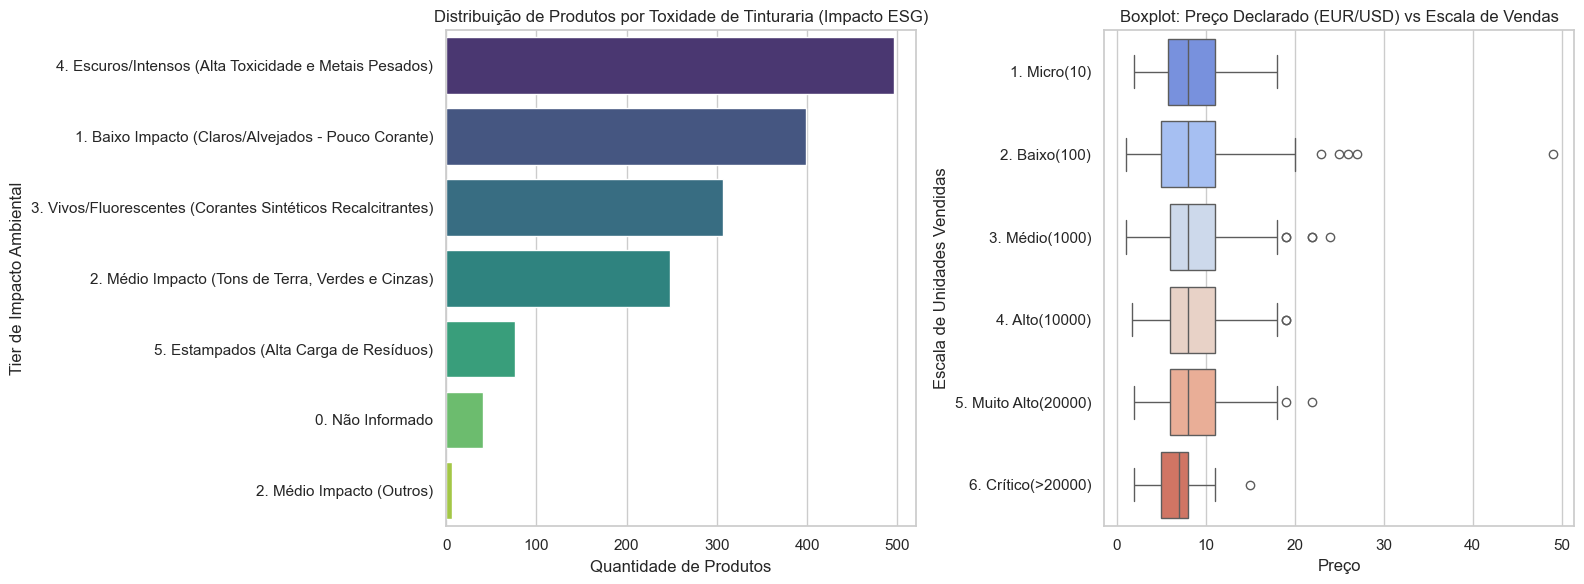

In [8]:
# Configurações estéticas globais (Seaborn)
sns.set_theme(style='whitegrid')
plt.figure(figsize=(16, 6))

# Gráfico 1: Análise de Portfólio vs. Impacto Ambiental
plt.subplot(1, 2, 1)
sns.countplot(y='product_color_GroupedByImpactFix', data=df, order=df['product_color_GroupedByImpactFix'].value_counts().index, palette='viridis')
plt.title('Distribuição de Produtos por Toxidade de Tinturaria (Impacto ESG)')
plt.xlabel('Quantidade de Produtos')
plt.ylabel('Tier de Impacto Ambiental')

# Gráfico 2: Relação entre Volume de Venda e Preço Real
plt.subplot(1, 2, 2)
sns.boxplot(x='price', y='units_sold_EscalaFix', data=df, palette='coolwarm')
plt.title('Boxplot: Preço Declarado (EUR/USD) vs Escala de Vendas')
plt.xlabel('Preço')
plt.ylabel('Escala de Unidades Vendidas')

plt.tight_layout()
plt.show()